# Метод главных компонент

Исследуем корреляции, определим необходимое число компонент для сохранения 95% дисперсии, проверим качество классификации и визуализируем объекты в пространстве первых двух компонент.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные и корреляции

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Размер: (178, 13)
Классы: {0: 59, 1: 71, 2: 48}


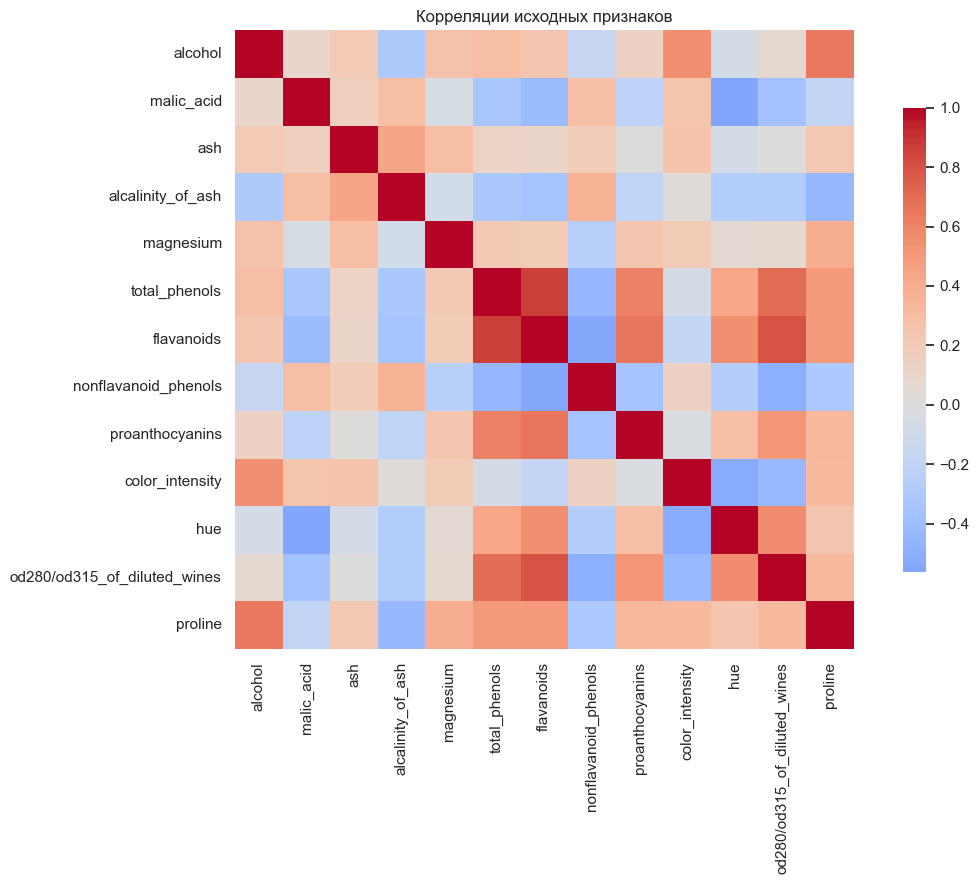

In [2]:
dataset = load_wine(as_frame=True)
features = dataset.data
target = dataset.target

display(features.head())
print("Размер:", features.shape)
print("Классы:", target.value_counts().sort_index().to_dict())

plt.figure(figsize=(12, 9))
sns.heatmap(features.corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.75})
plt.title("Корреляции исходных признаков")
plt.tight_layout()
plt.show()

## Объяснённая дисперсия

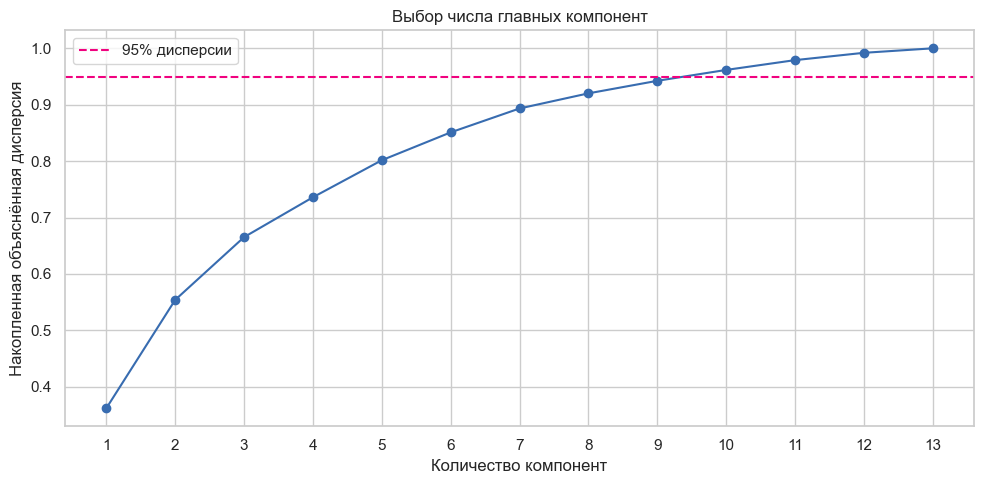

In [3]:
scaled_features = StandardScaler().fit_transform(features)
full_pca = PCA().fit(scaled_features)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", color="#386cb0")
plt.axhline(0.95, linestyle="--", color="#f0027f", label="95% дисперсии")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("Выбор числа главных компонент")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

## PCA и классификация

In [4]:
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)
pca = pipeline.named_steps["pca"]

pd.Series({
    "source_features": features.shape[1],
    "selected_components": pca.n_components_,
    "explained_variance": pca.explained_variance_ratio_.sum(),
    "accuracy": accuracy_score(test_target, prediction),
}).to_frame("value")

,value
source_features,13.000000
selected_components,10.000000
explained_variance,0.963720
accuracy,0.977778


## Двумерная проекция

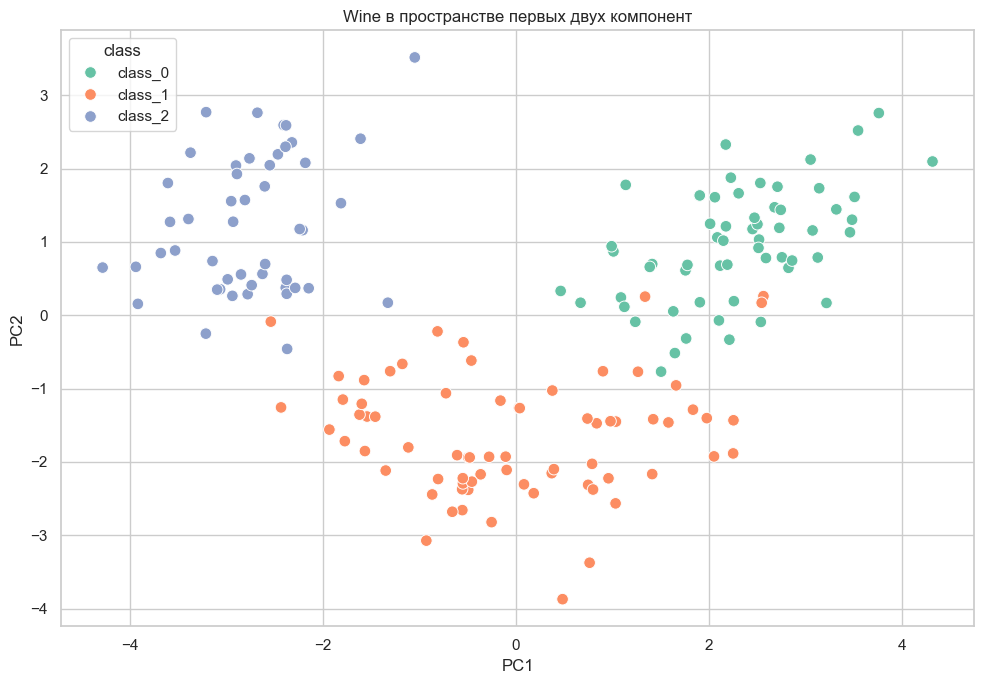

In [5]:
pca_2 = PCA(n_components=2)
projection = pca_2.fit_transform(scaled_features)
projection_frame = pd.DataFrame({
    "PC1": projection[:, 0],
    "PC2": projection[:, 1],
    "class": target.map(dict(enumerate(dataset.target_names))),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=projection_frame, x="PC1", y="PC2", hue="class", palette="Set2", s=70)
plt.title("Wine в пространстве первых двух компонент")
plt.tight_layout()
plt.show()

## Вклад признаков в первые компоненты

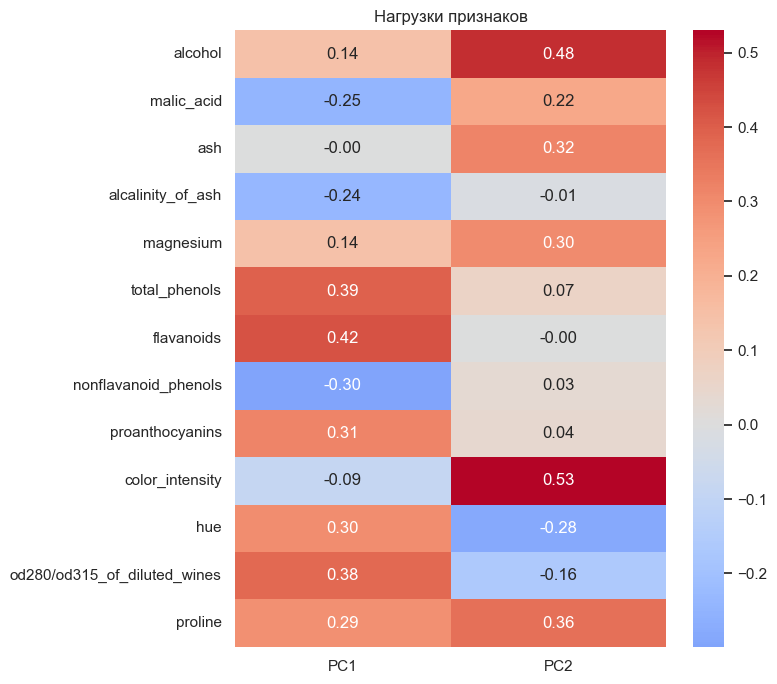

In [6]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=features.columns,
    columns=["PC1", "PC2"],
)

plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Нагрузки признаков")
plt.tight_layout()
plt.show()

## Вывод

PCA заменяет исходные коррелирующие признаки меньшим числом ортогональных компонент. Накопленная дисперсия помогает выбрать размерность, двумерная проекция показывает разделимость классов, а нагрузки объясняют вклад исходных признаков.